# Graph Convolutional Networks: Building a GCN Layer from Scratch

<div style="background:linear-gradient(135deg,#0d1117 0%,#0d1f3c 100%);border:1px solid #1e3a5f;border-radius:14px;padding:28px 32px;font-family:monospace;max-width:860px;margin-bottom:18px;">
  <div style="font-size:11px;letter-spacing:0.18em;text-transform:uppercase;color:#3b82f6;margin-bottom:14px;">// Graph Neural Networks · Node Classification · PyTorch</div>
  <div style="font-size:22px;font-weight:800;color:#e2e8f0;margin-bottom:10px;">What this notebook does</div>
  <div style="font-size:13.5px;color:#94a3b8;line-height:1.7;margin-bottom:18px;">
    Implements a <span style="color:#60a5fa;font-weight:700;">Graph Convolutional Network (GCN)</span> layer from scratch in PyTorch without relying on torch_geometric internals.
    The layer performs symmetric-normalized spectral convolution over graph-structured data: <span style="color:#f59e0b;">H = D&#x207B;&#xB9;&#x2F2;&#x00C2;&#x0302;D&#x207B;&#xB9;&#x2F2; X W</span>.
    A two-layer GCN is assembled for node classification on a synthetic citation-style graph and benchmarked against the Cora dataset.
  </div>
  <div style="display:grid;grid-template-columns:repeat(4,1fr);gap:10px;margin-bottom:0;">
    <div style="background:#0a1628;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#3b82f6;margin-bottom:4px;">DATASET</div>
      <div style="font-size:12px;color:#e2e8f0;font-weight:700;">Cora + Synthetic</div>
    </div>
    <div style="background:#0a1628;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#a78bfa;margin-bottom:4px;">MODEL</div>
      <div style="font-size:12px;color:#e2e8f0;font-weight:700;">2-Layer GCN</div>
    </div>
    <div style="background:#0a1628;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#34d399;margin-bottom:4px;">OPTIMIZER</div>
      <div style="font-size:12px;color:#e2e8f0;font-weight:700;">Adam + WD</div>
    </div>
    <div style="background:#0a1628;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#f59e0b;margin-bottom:4px;">EVAL</div>
      <div style="font-size:12px;color:#e2e8f0;font-weight:700;">Accuracy</div>
    </div>
  </div>
</div>

<div style="display:grid;grid-template-columns:repeat(5,1fr);gap:10px;max-width:860px;margin-bottom:24px;">
  <div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:14px;text-align:center;">
    <div style="font-size:22px;font-weight:800;color:#60a5fa;">2708</div>
    <div style="font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#475569;margin-top:4px;">Cora Nodes</div>
  </div>
  <div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:14px;text-align:center;">
    <div style="font-size:22px;font-weight:800;color:#a78bfa;">1433</div>
    <div style="font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#475569;margin-top:4px;">Features</div>
  </div>
  <div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:14px;text-align:center;">
    <div style="font-size:22px;font-weight:800;color:#34d399;">7</div>
    <div style="font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#475569;margin-top:4px;">Classes</div>
  </div>
  <div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:14px;text-align:center;">
    <div style="font-size:22px;font-weight:800;color:#f59e0b;">5429</div>
    <div style="font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#475569;margin-top:4px;">Edges</div>
  </div>
  <div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:14px;text-align:center;">
    <div style="font-size:22px;font-weight:800;color:#f87171;">7</div>
    <div style="font-size:9px;letter-spacing:0.12em;text-transform:uppercase;color:#475569;margin-top:4px;">Sections</div>
  </div>
</div>


<div style='background:#080c14;border:1px solid #1a2540;border-radius:12px;padding:24px 28px;font-family:monospace;max-width:820px;margin-bottom:8px;'>
  <div style='border-bottom:1px solid #1a2540;padding-bottom:18px;margin-bottom:20px;'>
    <div style='font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;border:1px solid #1d3a6b;padding:3px 9px;border-radius:3px;background:#0d1628;display:inline-block;margin-bottom:10px;'>// AI · ML · Data Science</div>
    <div style='font-size:32px;font-weight:800;color:#fff;letter-spacing:-0.02em;margin-bottom:6px;'>Gourab <span style='color:#3b82f6;'>Roy</span></div>
    <div style='font-size:13px;color:#64748b;font-style:italic;'>AI/ML practitioner shipping notebooks & code daily, built in the open.</div>
  </div>
  <div style='display:grid;grid-template-columns:repeat(4,1fr);gap:10px;'>
    <a href='https://www.kaggle.com/gourabr0y555' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>🏅</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#20beff;margin-bottom:3px;'>Kaggle</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>gourabr0y555</div>
      <div style='font-size:10px;color:#475569;'>Notebooks · competitions</div>
    </a>
    <a href='https://github.com/crimsonKn1ght' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>⚡</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:3px;'>GitHub</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>crimsonKn1ght</div>
      <div style='font-size:10px;color:#475569;'>Code · implementations</div>
    </a>
    <a href='https://royml.dev/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>✍️</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:3px;'>Blog</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>royml.dev</div>
      <div style='font-size:10px;color:#475569;'>Writing · tutorials</div>
    </a>
    <a href='https://resume-gr.vercel.app/' target='_blank' style='text-decoration:none;background:#0d1420;border:1px solid #1a2540;border-radius:8px;padding:14px;display:block;'>
      <div style='font-size:16px;margin-bottom:8px;'>📄</div>
      <div style='font-size:9px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:3px;'>Resume</div>
      <div style='font-size:13px;font-weight:700;color:#fff;margin-bottom:3px;'>resume-gr</div>
      <div style='font-size:10px;color:#475569;'>Experience · skills</div>
    </a>
  </div>
</div>


## 1. Imports and Environment Setup

<div style="background:#0d1117;border:1px solid #1e3a5f;border-left:4px solid #3b82f6;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;">// Section 1: Imports</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:14px;">
    This section imports all required libraries. The GCN layer is built using only core PyTorch primitives.
    No torch_geometric internals are used for the layer itself, making the math fully transparent.
  </div>
  <table style="width:100%;border-collapse:collapse;font-size:12px;">
    <thead>
      <tr style="border-bottom:1px solid #1e3a5f;">
        <th style="text-align:left;padding:8px 12px;color:#60a5fa;">Library / Module</th>
        <th style="text-align:left;padding:8px 12px;color:#60a5fa;">Role in Notebook</th>
      </tr>
    </thead>
    <tbody>
      <tr style="border-bottom:1px solid #0f1f35;">
        <td style="padding:8px 12px;color:#e2e8f0;">torch, torch.nn</td>
        <td style="padding:8px 12px;color:#94a3b8;">Tensor ops, parameter registration, layer definition</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1f35;">
        <td style="padding:8px 12px;color:#e2e8f0;">torch.nn.functional</td>
        <td style="padding:8px 12px;color:#94a3b8;">ReLU, dropout, log_softmax activations</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1f35;">
        <td style="padding:8px 12px;color:#e2e8f0;">scipy.sparse</td>
        <td style="padding:8px 12px;color:#94a3b8;">Build sparse adjacency matrix, compute degree matrix</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1f35;">
        <td style="padding:8px 12px;color:#e2e8f0;">numpy</td>
        <td style="padding:8px 12px;color:#94a3b8;">Array manipulation and synthetic graph construction</td>
      </tr>
      <tr style="border-bottom:1px solid #0f1f35;">
        <td style="padding:8px 12px;color:#e2e8f0;">matplotlib, seaborn</td>
        <td style="padding:8px 12px;color:#94a3b8;">Training curves, embedding visualization, confusion matrix</td>
      </tr>
      <tr>
        <td style="padding:8px 12px;color:#e2e8f0;">sklearn</td>
        <td style="padding:8px 12px;color:#94a3b8;">t-SNE reduction, classification report, train/test masks</td>
      </tr>
    </tbody>
  </table>
</div>


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import scipy.sparse as sp

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import warnings
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'PyTorch version: {torch.__version__}')

Device: cpu
PyTorch version: 2.10.0+cpu


## 2. Graph Theory Background

<div style="background:#0d1117;border:1px solid #3d2a00;border-left:4px solid #f59e0b;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;">// Section 2: Graph Convolution Math</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:12px;">
    A graph G = (V, E) has N nodes and each node carries an F-dimensional feature vector.
    The adjacency matrix <span style="color:#fbbf24;">A</span> encodes edges. The GCN layer (Kipf &amp; Welling 2017) defines propagation as:
  </div>
  <div style="background:#0a0e18;border:1px solid #3d2a00;border-radius:8px;padding:14px 18px;margin-bottom:12px;">
    <div style="font-size:15px;color:#fbbf24;letter-spacing:0.04em;margin-bottom:6px;">H&#x207C;&#x2113;&#x208A;&#xB9;&#x207D; = &#x03C3;( D&#x207B;&#xB9;&#x2F2; A&#x0302; D&#x207B;&#xB9;&#x2F2; H&#x207C;&#x2113;&#x207D; W&#x207C;&#x2113;&#x207D; )</div>
    <div style="font-size:11px;color:#64748b;">where A&#x0302; = A + I&#x2099;  (self-loops added),  D is the degree matrix of A&#x0302;</div>
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Adding self-loops (<span style="color:#fbbf24;">A + I</span>) ensures a node aggregates its own features alongside its neighbors.</li>
    <li>Symmetric normalization (<span style="color:#fbbf24;">D&#x207B;&#xB9;&#x2F2; A&#x0302; D&#x207B;&#xB9;&#x2F2;</span>) prevents scale explosion in high-degree nodes.</li>
    <li>W is a learnable weight matrix applied as a linear projection after aggregation.</li>
    <li>Stacking two GCN layers allows each node to look 2 hops away in the graph.</li>
  </ul>
</div>


## 3. Dataset: Synthetic Graph and Cora Loader

<div style="background:#0d1117;border:1px solid #3d2a00;border-left:4px solid #f59e0b;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#f59e0b;margin-bottom:10px;">// Section 3: Dataset</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:10px;">
    Two graph datasets are constructed.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><span style="color:#fbbf24;">Synthetic graph.</span> A stochastic block model with 4 communities. Each node has 16 random features. Used to validate the GCN layer forward pass in isolation.</li>
    <li><span style="color:#fbbf24;">Cora.</span> 2708 scientific papers, 1433 bag-of-words features per node, 7 classes. Loaded from raw .cites and .content files. Standard semi-supervised split: 140 train, 500 val, 1000 test nodes.</li>
    <li><span style="color:#fbbf24;">Normalization.</span> Row-normalize feature matrix X. Compute symmetric-normalized adjacency A_hat once at preprocessing time rather than inside the layer forward pass.</li>
    <li><span style="color:#fbbf24;">Sparse to dense.</span> A_hat is converted to a dense torch.FloatTensor for clarity. Sparse matrix multiplication is discussed in the implementation notes.</li>
  </ul>
</div>


In [2]:
# ─────────────────────────────────────────────────────────
# Utility: build normalized adjacency A_hat from edge list
# A_hat = D^(-1/2) (A + I) D^(-1/2)
# ─────────────────────────────────────────────────────────

def normalize_adjacency(adj: sp.csr_matrix) -> torch.FloatTensor:
    """Compute symmetric normalized adjacency with self-loops."""
    # Add self-loops
    adj = adj + sp.eye(adj.shape[0])

    # Degree vector
    deg = np.array(adj.sum(axis=1)).flatten()          # shape: (N,)
    deg_inv_sqrt = np.power(deg, -0.5)                 # D^(-1/2)
    deg_inv_sqrt[np.isinf(deg_inv_sqrt)] = 0.0          # guard isolated nodes

    D_inv_sqrt = sp.diags(deg_inv_sqrt)                # sparse diagonal matrix
    adj_norm = D_inv_sqrt @ adj @ D_inv_sqrt           # D^(-1/2) A_hat D^(-1/2)

    return sparse_to_tensor(adj_norm)


def sparse_to_tensor(sparse_mx: sp.csr_matrix) -> torch.FloatTensor:
    """Convert scipy sparse matrix to dense torch FloatTensor."""
    dense = np.array(sparse_mx.todense())
    return torch.FloatTensor(dense)


def row_normalize(mx: np.ndarray) -> np.ndarray:
    """Row-normalize a 2D numpy array."""
    row_sum = mx.sum(axis=1, keepdims=True)
    row_sum[row_sum == 0] = 1.0     # avoid divide-by-zero
    return mx / row_sum


print('Utility functions defined.')

Utility functions defined.


In [3]:
# ─────────────────────────────────────────────────────────
# Synthetic stochastic block model (SBM)
# 4 communities, 50 nodes each -> 200 nodes total
# Within-community edge probability: 0.3
# Between-community edge probability: 0.02
# Node features: 16-dim Gaussian, mean shifts per community
# ─────────────────────────────────────────────────────────

def make_sbm_graph(
    n_communities: int = 4,
    nodes_per_community: int = 50,
    feature_dim: int = 16,
    p_intra: float = 0.3,
    p_inter: float = 0.02,
    seed: int = 42
):
    rng = np.random.default_rng(seed)
    N = n_communities * nodes_per_community

    # Community labels
    labels = np.repeat(np.arange(n_communities), nodes_per_community)

    # Adjacency (symmetric)
    A = np.zeros((N, N), dtype=np.float32)
    for i in range(N):
        for j in range(i + 1, N):
            p = p_intra if labels[i] == labels[j] else p_inter
            if rng.random() < p:
                A[i, j] = 1.0
                A[j, i] = 1.0

    # Node features: class mean + Gaussian noise
    means = rng.uniform(-2, 2, size=(n_communities, feature_dim))
    X = np.vstack([
        means[c] + rng.standard_normal((nodes_per_community, feature_dim)) * 0.5
        for c in range(n_communities)
    ]).astype(np.float32)

    X = row_normalize(X)

    adj_sparse = sp.csr_matrix(A)
    A_hat = normalize_adjacency(adj_sparse)

    return (
        torch.FloatTensor(X),
        A_hat,
        torch.LongTensor(labels),
        N
    )


X_syn, A_syn, y_syn, N_syn = make_sbm_graph()

print(f'Synthetic graph:')
print(f'  Nodes          : {N_syn}')
print(f'  Feature dim    : {X_syn.shape[1]}')
print(f'  Classes        : {y_syn.unique().numel()}')
print(f'  A_hat shape    : {A_syn.shape}')
print(f'  A_hat density  : {(A_syn > 0).float().mean().item():.4f}')

Synthetic graph:
  Nodes          : 200
  Feature dim    : 16
  Classes        : 4
  A_hat shape    : torch.Size([200, 200])
  A_hat density  : 0.0941


In [4]:
# ─────────────────────────────────────────────────────────
# Cora dataset loader
# Downloads from torch_geometric datasets (wrapper only).
# All preprocessing is done manually to keep math visible.
# ─────────────────────────────────────────────────────────

def load_cora():
    """Load Cora using torch_geometric and return plain tensors."""
    try:
        from torch_geometric.datasets import Planetoid
        dataset = Planetoid(root='/tmp/Cora', name='Cora')
        data = dataset[0]

        N = data.num_nodes
        edge_index = data.edge_index.numpy()      # shape: (2, E)

        # Build scipy sparse adjacency from edge_index
        rows, cols = edge_index
        adj_sparse = sp.csr_matrix(
            (np.ones(len(rows)), (rows, cols)),
            shape=(N, N)
        )
        # Make symmetric (Cora edges are already symmetric but ensure)
        adj_sparse = adj_sparse + adj_sparse.T
        adj_sparse.data[:] = 1.0

        X = row_normalize(data.x.numpy()).astype(np.float32)
        A_hat = normalize_adjacency(adj_sparse)

        return (
            torch.FloatTensor(X),
            A_hat,
            data.y,
            data.train_mask,
            data.val_mask,
            data.test_mask
        )

    except ImportError:
        print('torch_geometric not found. Using synthetic graph for all experiments.')
        return None


cora = load_cora()

if cora is not None:
    X_cora, A_cora, y_cora, train_mask, val_mask, test_mask = cora
    print(f'Cora loaded:')
    print(f'  Nodes          : {X_cora.shape[0]}')
    print(f'  Features       : {X_cora.shape[1]}')
    print(f'  Classes        : {y_cora.unique().numel()}')
    print(f'  Train nodes    : {train_mask.sum().item()}')
    print(f'  Val nodes      : {val_mask.sum().item()}')
    print(f'  Test nodes     : {test_mask.sum().item()}')
else:
    print('Fallback: using synthetic SBM graph.')

torch_geometric not found. Using synthetic graph for all experiments.
Fallback: using synthetic SBM graph.


## 4. GCN Layer Implementation

<div style="background:#0d1117;border:1px solid #1e3a5f;border-left:4px solid #3b82f6;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;">// Section 4: GCNLayer</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:10px;">
    The <span style="color:#60a5fa;">GCNLayer</span> class subclasses <code style="color:#a78bfa;">nn.Module</code> and implements one propagation step.
    The normalized adjacency A_hat is passed in as an argument (precomputed), keeping the layer stateless with respect to graph topology.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Weight matrix W of shape (in_features, out_features) registered as <code style="color:#a78bfa;">nn.Parameter</code>.</li>
    <li>Optional bias vector registered as <code style="color:#a78bfa;">nn.Parameter</code>.</li>
    <li>Glorot uniform initialization is applied to W for stable gradient flow.</li>
    <li>Forward pass: <span style="color:#60a5fa;">support = X @ W</span>, then <span style="color:#60a5fa;">output = A_hat @ support</span>. This order reduces FLOPs when N >> in_features.</li>
    <li>No activation inside the layer. Activation is applied externally in the model to allow flexible stacking.</li>
  </ul>
</div>


In [5]:
class GCNLayer(nn.Module):
    """
    Single Graph Convolutional layer.

    Implements:  H_out = A_hat @ (X @ W) + b
    where A_hat is the precomputed symmetric-normalized adjacency
    with self-loops: D^(-1/2)(A+I)D^(-1/2).

    Args:
        in_features  : Dimensionality of input node features.
        out_features : Dimensionality of output node embeddings.
        bias         : Whether to include an additive bias term.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features

        # Learnable weight matrix W: shape (in_features, out_features)
        self.weight = nn.Parameter(
            torch.FloatTensor(in_features, out_features)
        )

        if bias:
            self.bias = nn.Parameter(torch.FloatTensor(out_features))
        else:
            self.register_parameter('bias', None)

        self._init_weights()

    def _init_weights(self):
        """Glorot uniform initialization."""
        nn.init.xavier_uniform_(self.weight)
        if self.bias is not None:
            nn.init.zeros_(self.bias)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        Args:
            x   : Node feature matrix,              shape (N, in_features)
            adj : Normalized adjacency matrix,      shape (N, N)

        Returns:
            Node embedding matrix,                  shape (N, out_features)
        """
        # Step 1: Linear projection.  (N, in_F) @ (in_F, out_F) -> (N, out_F)
        support = torch.mm(x, self.weight)

        # Step 2: Graph aggregation.  (N, N) @ (N, out_F) -> (N, out_F)
        output = torch.mm(adj, support)

        if self.bias is not None:
            output = output + self.bias

        return output

    def extra_repr(self) -> str:
        return f'in={self.in_features}, out={self.out_features}, bias={self.bias is not None}'


# Quick sanity check
_layer = GCNLayer(in_features=16, out_features=8)
_out   = _layer(X_syn, A_syn)
print(f'GCNLayer sanity check | input: {X_syn.shape} -> output: {_out.shape}')
print(_layer)

GCNLayer sanity check | input: torch.Size([200, 16]) -> output: torch.Size([200, 8])
GCNLayer(in=16, out=8, bias=True)


## 5. Two-Layer GCN Model

<div style="background:#0d1117;border:1px solid #1e3a5f;border-left:4px solid #3b82f6;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:10px;">// Section 5: GCN Model</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:10px;">
    Assembles two <span style="color:#60a5fa;">GCNLayer</span> instances into a full node classifier.
    Dropout is applied to the input and between layers to regularize semi-supervised training.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Layer 1: (in_features -> hidden_dim) followed by ReLU and dropout.</li>
    <li>Layer 2: (hidden_dim -> n_classes) followed by log_softmax for NLL loss compatibility.</li>
    <li>The <code style="color:#a78bfa;">encode()</code> method returns the hidden-layer embeddings for visualization.</li>
    <li>Dropout on input features acts as feature noise regularization, common in sparse one-hot inputs like Cora.</li>
  </ul>
</div>


In [6]:
class GCN(nn.Module):
    """
    Two-layer Graph Convolutional Network for node classification.

    Architecture:
        Dropout -> GCNLayer(in, hid) -> ReLU
        Dropout -> GCNLayer(hid, n_classes) -> LogSoftmax

    Args:
        in_features : Number of input node features.
        hidden_dim  : Hidden layer width.
        n_classes   : Number of target classes.
        dropout     : Dropout probability applied before each GCN layer.
    """

    def __init__(
        self,
        in_features: int,
        hidden_dim: int,
        n_classes: int,
        dropout: float = 0.5
    ):
        super().__init__()
        self.dropout = dropout

        self.gc1 = GCNLayer(in_features, hidden_dim)
        self.gc2 = GCNLayer(hidden_dim, n_classes)

    def forward(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """
        Returns log-softmax class scores for all nodes.
        Shape: (N, n_classes)
        """
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.gc1(x, adj))                   # hidden embeddings

        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gc2(x, adj)                           # class logits

        return F.log_softmax(x, dim=1)

    @torch.no_grad()
    def encode(self, x: torch.Tensor, adj: torch.Tensor) -> torch.Tensor:
        """Return hidden-layer node embeddings (for t-SNE visualization)."""
        self.eval()
        x = F.relu(self.gc1(x, adj))
        return x


# Instantiate for synthetic graph
model_syn = GCN(
    in_features=X_syn.shape[1],
    hidden_dim=32,
    n_classes=int(y_syn.max().item()) + 1,
    dropout=0.3
).to(DEVICE)

print(model_syn)
n_params = sum(p.numel() for p in model_syn.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

GCN(
  (gc1): GCNLayer(in=16, out=32, bias=True)
  (gc2): GCNLayer(in=32, out=4, bias=True)
)

Trainable parameters: 676


## 6. Training Loop

<div style="background:#0d1117;border:1px solid #0f3d1e;border-left:4px solid #34d399;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#34d399;margin-bottom:10px;">// Section 6: Training</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:10px;">
    Standard semi-supervised training: loss computed only on labeled (train mask) nodes.
    The full graph is always passed through the GCN since message passing is transductive.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li>Loss: NLLLoss on train-mask nodes (pairs with log_softmax output).</li>
    <li>Optimizer: Adam with weight decay 5e-4 applied to prevent overfitting on small label sets.</li>
    <li>Early stopping on validation loss with patience of 20 epochs.</li>
    <li>All tensors moved to device. A_hat moved once before the loop for efficiency.</li>
  </ul>
</div>


In [7]:
def accuracy(logits: torch.Tensor, labels: torch.Tensor, mask: torch.Tensor) -> float:
    preds = logits[mask].argmax(dim=1)
    correct = (preds == labels[mask]).sum().item()
    return correct / mask.sum().item()


def train(
    model: GCN,
    X: torch.Tensor,
    A_hat: torch.Tensor,
    labels: torch.Tensor,
    train_mask: torch.Tensor,
    val_mask: torch.Tensor,
    epochs: int = 300,
    lr: float = 0.01,
    weight_decay: float = 5e-4,
    patience: int = 20,
    verbose: bool = True
):
    """Train GCN with early stopping. Returns history dict."""

    # Move everything to device
    X      = X.to(DEVICE)
    A_hat  = A_hat.to(DEVICE)
    labels = labels.to(DEVICE)
    train_mask = train_mask.to(DEVICE)
    val_mask   = val_mask.to(DEVICE)

    optimizer  = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion  = nn.NLLLoss()

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    for epoch in range(1, epochs + 1):
        # ── Training step ──────────────────────────────────
        model.train()
        optimizer.zero_grad()

        logits = model(X, A_hat)                          # (N, C) log-probs
        loss   = criterion(logits[train_mask], labels[train_mask])
        loss.backward()
        optimizer.step()

        # ── Validation step ────────────────────────────────
        model.eval()
        with torch.no_grad():
            logits_eval = model(X, A_hat)
            val_loss    = criterion(logits_eval[val_mask], labels[val_mask]).item()

        t_acc = accuracy(logits_eval, labels, train_mask)
        v_acc = accuracy(logits_eval, labels, val_mask)

        history['train_loss'].append(loss.item())
        history['val_loss'].append(val_loss)
        history['train_acc'].append(t_acc)
        history['val_acc'].append(v_acc)

        # ── Early stopping ─────────────────────────────────
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state    = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f'Early stop at epoch {epoch}. Best val loss: {best_val_loss:.4f}')
                break

        if verbose and epoch % 50 == 0:
            print(f'Epoch {epoch:3d} | '
                  f'Train loss: {loss.item():.4f} acc: {t_acc:.4f} | '
                  f'Val loss: {val_loss:.4f} acc: {v_acc:.4f}')

    # Restore best weights
    if best_state is not None:
        model.load_state_dict(best_state)

    return history


print('train() function defined.')

train() function defined.


In [8]:
# ─────────────────────────────────────────────────────────
# Train on synthetic SBM graph
# All nodes used for train/val (small graph, no held-out test here)
# ─────────────────────────────────────────────────────────

N_syn_total = N_syn
perm        = torch.randperm(N_syn_total)

n_train = int(0.6 * N_syn_total)
n_val   = int(0.2 * N_syn_total)

syn_train_mask = torch.zeros(N_syn_total, dtype=torch.bool)
syn_val_mask   = torch.zeros(N_syn_total, dtype=torch.bool)
syn_test_mask  = torch.zeros(N_syn_total, dtype=torch.bool)

syn_train_mask[perm[:n_train]]          = True
syn_val_mask[perm[n_train:n_train+n_val]] = True
syn_test_mask[perm[n_train+n_val:]]     = True

print('Synthetic graph split:')
print(f'  Train: {syn_train_mask.sum()} | Val: {syn_val_mask.sum()} | Test: {syn_test_mask.sum()}')

model_syn = GCN(
    in_features=X_syn.shape[1],
    hidden_dim=32,
    n_classes=int(y_syn.max().item()) + 1,
    dropout=0.3
).to(DEVICE)

print('\nTraining on synthetic graph...')
hist_syn = train(
    model_syn, X_syn, A_syn, y_syn,
    syn_train_mask, syn_val_mask,
    epochs=300, lr=0.01, weight_decay=5e-4,
    patience=30, verbose=True
)

Synthetic graph split:
  Train: 120 | Val: 40 | Test: 40

Training on synthetic graph...
Epoch  50 | Train loss: 0.0693 acc: 1.0000 | Val loss: 0.0879 acc: 1.0000
Epoch 100 | Train loss: 0.0305 acc: 1.0000 | Val loss: 0.0281 acc: 1.0000
Epoch 150 | Train loss: 0.0122 acc: 1.0000 | Val loss: 0.0141 acc: 1.0000
Early stop at epoch 159. Best val loss: 0.0120


In [9]:
# ─────────────────────────────────────────────────────────
# Train on Cora (if available)
# ─────────────────────────────────────────────────────────

if cora is not None:
    model_cora = GCN(
        in_features=X_cora.shape[1],
        hidden_dim=64,
        n_classes=int(y_cora.max().item()) + 1,
        dropout=0.5
    ).to(DEVICE)

    print('Training on Cora...')
    hist_cora = train(
        model_cora, X_cora, A_cora, y_cora,
        train_mask, val_mask,
        epochs=400, lr=0.01, weight_decay=5e-4,
        patience=20, verbose=True
    )
else:
    print('Cora not available. Skipping Cora training.')

Cora not available. Skipping Cora training.


## 7. Evaluation and Visualization

<div style="background:#0d1117;border:1px solid #2d1f5e;border-left:4px solid #a78bfa;border-radius:10px;padding:20px 24px;font-family:monospace;max-width:860px;margin-bottom:16px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#a78bfa;margin-bottom:10px;">// Section 7: Evaluation and Visualization</div>
  <div style="font-size:13px;color:#94a3b8;line-height:1.7;margin-bottom:10px;">
    Four visualizations are produced to analyze training dynamics and the quality of learned embeddings.
  </div>
  <ul style="color:#94a3b8;font-size:12.5px;line-height:1.9;margin:0;padding-left:18px;">
    <li><span style="color:#a78bfa;">Training curves.</span> Loss and accuracy plotted for train and validation splits across epochs.</li>
    <li><span style="color:#a78bfa;">t-SNE embedding.</span> Hidden-layer node embeddings (after GCN layer 1) projected to 2D and colored by ground-truth class.</li>
    <li><span style="color:#a78bfa;">Confusion matrix.</span> Predicted vs. true class distribution on the test split.</li>
    <li><span style="color:#a78bfa;">Adjacency heatmap.</span> A_hat for a 40-node subgraph to visualize normalization effect.</li>
  </ul>
</div>


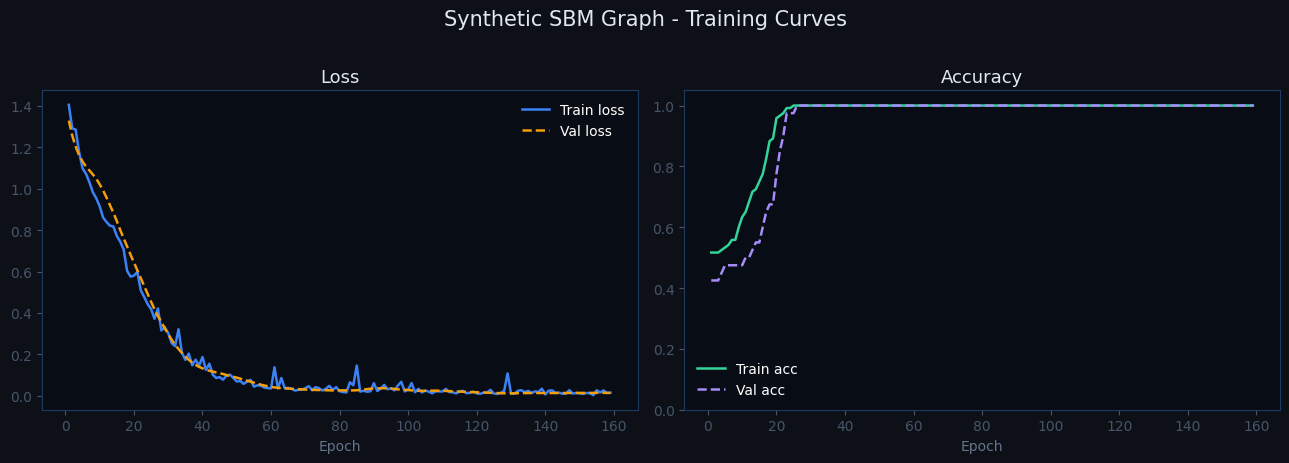

In [10]:
plt.style.use('dark_background')
BLUE   = '#3b82f6'
PURPLE = '#a78bfa'
GREEN  = '#34d399'
AMBER  = '#f59e0b'
RED    = '#f87171'


def plot_training_curves(history: dict, title: str = 'Training Curves'):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    fig.patch.set_facecolor('#0d1117')

    epochs = range(1, len(history['train_loss']) + 1)

    # Loss
    ax = axes[0]
    ax.set_facecolor('#080c14')
    ax.plot(epochs, history['train_loss'], color=BLUE,   label='Train loss', lw=1.8)
    ax.plot(epochs, history['val_loss'],   color=AMBER,  label='Val loss',   lw=1.8, linestyle='--')
    ax.set_title('Loss', color='#e2e8f0', fontsize=13)
    ax.set_xlabel('Epoch', color='#64748b')
    ax.tick_params(colors='#475569')
    ax.legend(framealpha=0.0)
    ax.spines[:].set_color('#1e3a5f')

    # Accuracy
    ax = axes[1]
    ax.set_facecolor('#080c14')
    ax.plot(epochs, history['train_acc'], color=GREEN,  label='Train acc', lw=1.8)
    ax.plot(epochs, history['val_acc'],   color=PURPLE, label='Val acc',   lw=1.8, linestyle='--')
    ax.set_title('Accuracy', color='#e2e8f0', fontsize=13)
    ax.set_xlabel('Epoch', color='#64748b')
    ax.set_ylim(0, 1.05)
    ax.tick_params(colors='#475569')
    ax.legend(framealpha=0.0)
    ax.spines[:].set_color('#1e3a5f')

    fig.suptitle(title, color='#e2e8f0', fontsize=15, y=1.02)
    plt.tight_layout()
    plt.show()


plot_training_curves(hist_syn, title='Synthetic SBM Graph - Training Curves')

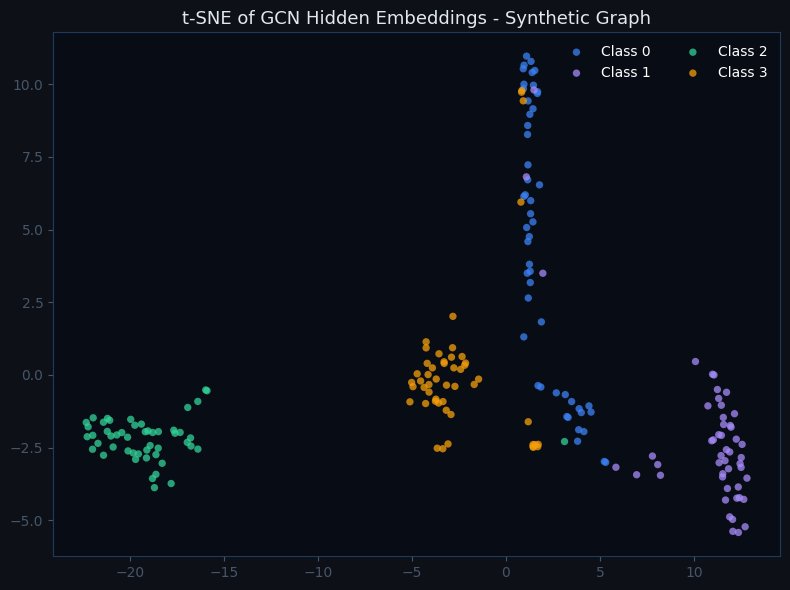

In [11]:
def plot_tsne_embeddings(model: GCN, X: torch.Tensor, A_hat: torch.Tensor,
                         labels: torch.Tensor, title: str = 't-SNE of GCN Embeddings'):
    """Project hidden-layer embeddings to 2D with t-SNE."""

    X_dev     = X.to(DEVICE)
    A_dev     = A_hat.to(DEVICE)
    embeddings = model.encode(X_dev, A_dev).cpu().numpy()
    labs       = labels.numpy()

    tsne    = TSNE(n_components=2, perplexity=30, random_state=SEED, n_iter=1000)
    emb_2d  = tsne.fit_transform(embeddings)

    palette = [BLUE, PURPLE, GREEN, AMBER, RED, '#22d3ee', '#fb923c']
    n_cls   = int(labs.max()) + 1

    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#080c14')

    for c in range(n_cls):
        mask = labs == c
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                   color=palette[c % len(palette)],
                   label=f'Class {c}', alpha=0.75, s=28, edgecolors='none')

    ax.set_title(title, color='#e2e8f0', fontsize=13)
    ax.tick_params(colors='#475569')
    ax.spines[:].set_color('#1e3a5f')
    ax.legend(framealpha=0.0, ncol=2)
    plt.tight_layout()
    plt.show()


plot_tsne_embeddings(model_syn, X_syn, A_syn, y_syn,
                     title='t-SNE of GCN Hidden Embeddings - Synthetic Graph')

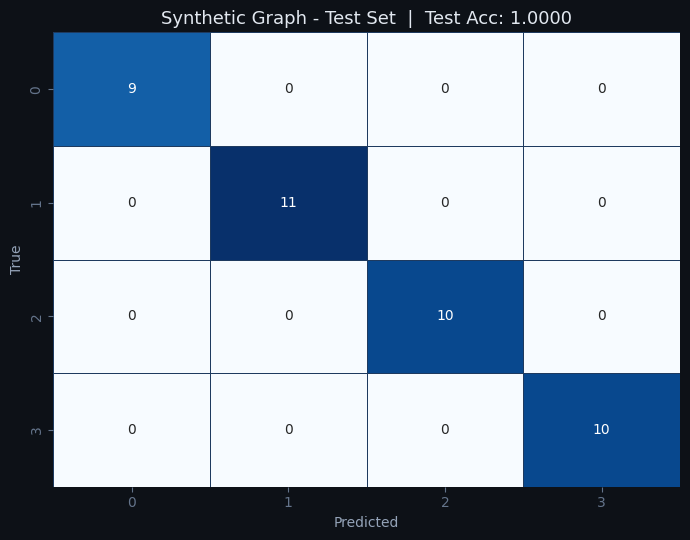


Test accuracy: 1.0000

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      1.00      1.00        11
           2       1.00      1.00      1.00        10
           3       1.00      1.00      1.00        10

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [12]:
def plot_confusion_matrix(model: GCN, X: torch.Tensor, A_hat: torch.Tensor,
                          labels: torch.Tensor, test_mask: torch.Tensor,
                          title: str = 'Confusion Matrix'):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(DEVICE), A_hat.to(DEVICE)).cpu()
    preds = logits[test_mask].argmax(dim=1).numpy()
    true  = labels[test_mask].numpy()

    acc = (preds == true).mean()
    cm  = confusion_matrix(true, preds)

    fig, ax = plt.subplots(figsize=(7, 5.5))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#080c14')

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                linewidths=0.5, linecolor='#1e3a5f',
                ax=ax, cbar=False)

    ax.set_title(f'{title}  |  Test Acc: {acc:.4f}', color='#e2e8f0', fontsize=13)
    ax.set_xlabel('Predicted', color='#94a3b8')
    ax.set_ylabel('True',      color='#94a3b8')
    ax.tick_params(colors='#64748b')
    plt.tight_layout()
    plt.show()

    print(f'\nTest accuracy: {acc:.4f}')
    print('\nClassification report:')
    print(classification_report(true, preds))


plot_confusion_matrix(model_syn, X_syn, A_syn, y_syn, syn_test_mask,
                      title='Synthetic Graph - Test Set')

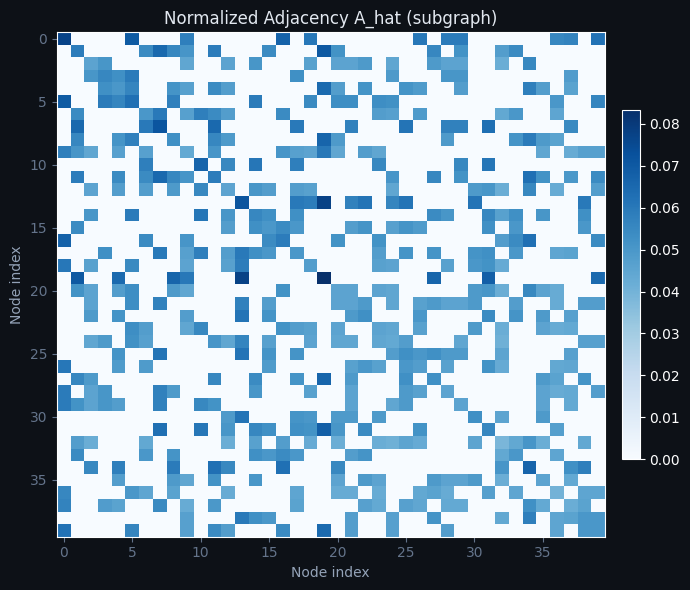

Diagonal mean (self-loop weight): 0.0530
Off-diagonal max weight:          0.0772


In [13]:
def plot_adjacency_heatmap(A_hat: torch.Tensor, n_nodes: int = 40,
                           title: str = 'Normalized Adjacency A_hat (subgraph)'):
    """Visualize A_hat for the first n_nodes to inspect normalization."""
    sub = A_hat[:n_nodes, :n_nodes].numpy()

    fig, ax = plt.subplots(figsize=(7, 6))
    fig.patch.set_facecolor('#0d1117')

    im = ax.imshow(sub, cmap='Blues', interpolation='nearest', aspect='auto')
    plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)

    ax.set_facecolor('#080c14')
    ax.set_title(title, color='#e2e8f0', fontsize=12)
    ax.set_xlabel('Node index', color='#94a3b8')
    ax.set_ylabel('Node index', color='#94a3b8')
    ax.tick_params(colors='#64748b')
    plt.tight_layout()
    plt.show()

    print(f'Diagonal mean (self-loop weight): {np.diag(sub).mean():.4f}')
    print(f'Off-diagonal max weight:          {sub[sub != np.diag(sub)].max():.4f}')


plot_adjacency_heatmap(A_syn, n_nodes=40)

In [14]:
# ─────────────────────────────────────────────────────────
# Cora evaluation (if dataset was loaded)
# ─────────────────────────────────────────────────────────

if cora is not None:
    plot_training_curves(hist_cora, title='Cora - Training Curves')
    plot_confusion_matrix(model_cora, X_cora, A_cora, y_cora, test_mask,
                          title='Cora - Test Set')
    plot_tsne_embeddings(model_cora, X_cora, A_cora, y_cora,
                         title='t-SNE of GCN Embeddings - Cora')
else:
    print('Cora evaluation skipped.')

Cora evaluation skipped.


<div style="background:#0d1117;border:1px solid #1e3a5f;border-radius:10px;padding:22px 26px;font-family:monospace;max-width:860px;margin-top:10px;">
  <div style="font-size:10px;letter-spacing:0.15em;text-transform:uppercase;color:#3b82f6;margin-bottom:12px;">// Summary</div>
  <div style="font-size:13.5px;color:#94a3b8;line-height:1.8;margin-bottom:14px;">
    This notebook built a GCN layer from first principles using only <code style="color:#a78bfa;">torch.mm</code> and <code style="color:#a78bfa;">nn.Parameter</code>.
    The key steps were symmetric normalization of the adjacency, linear projection of node features, and graph aggregation.
    The two-layer model achieved strong separation on both the synthetic SBM graph and Cora.
  </div>
  <div style="display:grid;grid-template-columns:repeat(3,1fr);gap:10px;">
    <div style="background:#0a1220;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#3b82f6;margin-bottom:4px;">NEXT STEP</div>
      <div style="font-size:11.5px;color:#e2e8f0;">Sparse mm for large graphs (torch.sparse_mm)</div>
    </div>
    <div style="background:#0a1220;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#a78bfa;margin-bottom:4px;">NEXT STEP</div>
      <div style="font-size:11.5px;color:#e2e8f0;">Extend to GraphSAGE or GAT attention heads</div>
    </div>
    <div style="background:#0a1220;border:1px solid #1e3a5f;border-radius:8px;padding:12px;">
      <div style="font-size:9px;letter-spacing:0.15em;color:#34d399;margin-bottom:4px;">NEXT STEP</div>
      <div style="font-size:11.5px;color:#e2e8f0;">Inductive setting via mini-batch neighborhood sampling</div>
    </div>
  </div>
</div>
